In [1]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from numpy.ma.core import less_equal
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# Create Model
m = gp.Model("Model_1")

Set parameter Username
Set parameter LicenseID to value 2592148
Academic license - for non-commercial use only - expires 2025-11-27


In [3]:
# GENERAL PARAMETERS

# Number of vehicle types
V = 6

# Number of nodes i,j
nodes = 4

# I, J = nodes, nodes
arcs = {i: [j for j in range(nodes) if abs(i - j) <= 1] for i in range(nodes)}

# Time Steps 12 (days) #testing with +1 day
T = 12

# Commodity variable types
X = [GRB.INTEGER, GRB.CONTINUOUS, GRB.CONTINUOUS, GRB.CONTINUOUS, GRB.CONTINUOUS, GRB.INTEGER]
# Crew, consumables, equipment, samples, propellant, crew return

Y = GRB.INTEGER
# Spacecrafts of same type

In [4]:
# ASSUMPTIONS

# Consumption rates [kg/crew/day]
food_consumption = 1.0
water_consumption = 5.0
oxygen_consumption = 1.1
consumption = food_consumption + water_consumption + oxygen_consumption

# Crew mass [kg/crew]
crew_mass = 100

# Gravitational acceleration [m/sˆ2]
g_0 = 9.80665


In [5]:
# VEHICLE DATA

"""
#Simplified test data
# Structure mass [kg]
s = np.array([40000, 15000, ])

# Specific impulses [s]
I_sp = np.array([421, 324])

# Payload Capacity [kg]
C = np.array([5000, 2500])

# Propellant Capacity [kg]
M = np.array([1200770, 400000])
"""

#Vehicles: [Saturn V stage 2, Saturn V stage 3, Command Module, Service Module, LM Descent Stage, LM ascent stage]
# Because the intermediate nodes are travel between LEO and LLO the boosters are most useful
# during each arc only 1 spacecraft is expelling propellant
#this is the done in descending order as follows, the number corresponds to the vehicle
#so when 0 is present, it is using propellant,when 1 is present but not 0 then1 is using propellant
#when 5 is present but not 0 or 1 then it is using fuel
#this is ensured by a series of conditions, where for certain arcs, specific SC are required
#e.g LEO to LLO requires a stage (2nd or 3rd stage), landing on the moon requires the ascent module and leaving the moon requires the descent module
burn_order = [0,1,5,4,3,2] # the command module (2) has no isp so is at the end of the burn order



# Structure mass [kg]
s = np.array([38415, 12014, 4841, 6053, 2770, 1719])

# Specific impulses [s]
I_sp = np.array([421, 421, 0, 314, 311, 311])

# Payload Capacity [kg]
C = np.array([0, 0, 524, 60, 500, 250])

# Propellant Capacity [kg] 
M = np.array([452045, 107725, 0, 18413, 8804, 2358])

# Commodity variable types
# Crew, consumables, equipment, samples, propellant, crew return
# Upper limit of each variable is the capacity of each
XUpper = [C/crew_mass,C,C,C,M,C/crew_mass]


In [6]:
# DISPLACEMENT DATA

# Velocity change [km/s]
# PAC, LEO, LLO, LS are 0, 1, 2, 3
delta_V = {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0, 2: 4.04}, 2: {1: 4.04, 2: 0, 3: 1.87}, 3: {2: 1.87, 3: 0}}

# Time of travel [days]
TOF = {0: {0: 1, 1: 1}, 1: {0: 1, 1: 1, 2: 3}, 2: {1: 3, 2: 1, 3: 1}, 3: {2: 1, 3: 1}}

# Required module (if none are necessary then type 4, as it is the last in burn_order and has no dependencies)
#So all are separate vehicles
#caveat: 2 options will be made for 0 and 1 vehicles, to test out either 2 boosters or just 1
#this only affects 1:2
Req_SC = {0: {0: 3, 1: 3}, 1: {0: 3, 1: 3, 2: 0}, 2: {1: 3, 2: 3, 3: 5}, 3: {2: 3, 3: 3}}


# Propellant mass fraction
phi = [[{j: 1 - np.exp(-(delta_V[i][j] / (I_sp[v] * g_0))) if I_sp[v] != 0 else 1 for j in arcs[i]}
        for i in arcs]
       for v in range(V)]




In [7]:
# CREATE COMMODITY FLOW VECTORS AND S/C COMMODITY FLOW
# Variable naming process: commodity_{direction}flow_{v},{i},{j},{t},{x}'
# Variable naming process: sc_commodity_{direction}flow_{v},{i},{j},{t}'

def create_commodity_flow(model, V, arcs, T, X, direction):
    
    x_flow = [[{j: [np.array([[model.addVar(vtype=X[x], name=f'commodity_{direction}flow_{v},{i},{j},{t},{x}', ub =XUpper[x][v]  )]
                              for x in range(len(X))])
                    for t in range(T-1)]
                for j in arcs[i]}
               for i in arcs]
              for v in range(V)]

    return x_flow


def create_sc_commodity_flow(model, V, arcs, T, Y, direction):
    y_flow = [
        [{j: [np.array([model.addVar(vtype=Y, name=f'sc_commodity_{direction}flow_{v},{i},{j},{t}')]) for t in range(T-1)]
          for j in arcs[i]}
         for i in arcs]
        for v in range(V)]

    return y_flow

# Outflow+ leaving from node i to j, inflow- arriving at node j from i

x_outflow, x_inflow = create_commodity_flow(m, V, arcs, T, X, "out"), create_commodity_flow(m, V, arcs, T, X, "in")
y_outflow, y_inflow = create_sc_commodity_flow(m, V, arcs, T, Y, "out"), create_sc_commodity_flow(m, V, arcs, T, Y, "in")

m.update()


In [8]:
# CONSTRAINTS 2 & 3 MASS BALANCE
# Node commodity demand D vectors (positive for supply)
# sum(x[i][t]+) - sum(x[i][t]-) <= D[i][t]
# x = Crew, consumables, equipment, Lunar samples, propellant, crew return

# COMMODITY DEMAND

# THE COMMODITIES ARE PROVIDED AT LEO ???? START ALL THINGS AT LEO
# CHECK DAYS FOR MISSION !!!
#Commodity Array: D[Node][Day][Commodity]

D = [[np.array([0 for x in range(len(X))])
      for _ in range(T)]
    for _ in arcs]

print(len(D))
print(len(D[0]))
print(len(D[0][0]))

# Earth (PAC) crew, consumables, equipment, propellant supply infinite at leo time 0, AND Moon surface sample supply (infinite at all times)
D[1][0][0] = 99999 #Crew
D[1][0][1] = 99999 #Consumables
D[1][0][2] = 99999 #Equipment
D[1][0][4] = 9999999 #Propellant

for x in range(T):
    D[3][x][3] = 999999


# APOLLO

# for t in range(T):
#     D[1][t] = np.array([999999 if x != 3 else 0 for x in range(len(X))])
#     D[3][t][3] = 999999

# Crew demand/supply
D[3][4][0] = -2 # Lunar surface day 5 crew demand (negative supply)
D[2][3][0] = -1 # Lunar orbit day 4 crew demand
D[3][5][5] = 2 # Lunar surface day 6 crew supply (return)
D[2][6][5] = 1 # Lunar orbit day 7 crew supply (return)
D[0][10][5] = -3 # Earth day 11 crew demand (return)

D[3][4][2] = -420 # Lunar surface day 5 (scientific) equipment demand

D[0][10][3] = -110 # Earth day 11 lunar sample demand


"""
#attempting to move all demand+supply by 1 day
D[3][5][0] = -2 # Lunar surface day 6 crew demand (negative supply)
D[2][4][0] = -1 # Lunar orbit day 5 crew demand
D[3][6][5] = 2 # Lunar surface day 7 crew supply (return)
D[2][7][5] = 1 # Lunar orbit day 8 crew supply (return)
D[0][11][5] = -3 # Earth day 12 crew demand (return)

D[3][5][2] = -420 # Lunar surface day 6 (scientific) equipment demand

D[0][11][3] = -110 # Earth day 12 lunar sample demand
"""

# S/C COMMODITY DEMAND
# format d[node][vehicle][day]
d = [[[99 if (i == 1 and t == 0) else 0 for t in range(T)] # Infinite supply of spacecrafts at i = 1, t = 0 LEO
     for _ in range(V)]
    for i in arcs]
print(d)



4
12
6
[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[99, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [99, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [99, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [99, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [99, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [99, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]]


In [9]:
# ADD THE CONSTRAINTS (2 & 3)

for i in arcs:
    for t in range(T):

        x_outflow_sum = sum(x_outflow[v][i][j][t] for v in range(V) for j in arcs[i]) if t < T-1 \
            else np.array([[0] for _ in range(len(X))])
        # On the last day there is no outflow
    

        x_inflow_sum = sum(x_inflow[v][j][i][t - TOF[j][i]] if t >= TOF[j][i]
                           else np.array([[0] for _ in range(len(X))])
                           for v in range(V) for j in arcs[i])
        # Only count the inflows for which the spacecraft has had time to arrive

        for x in range(len(X)):
            m.addConstr(x_outflow_sum[x][0] - x_inflow_sum[x][0] <= D[i][t][x])

        # S/C commodity supply and demand
        for v in range(V):
            y_outflow_sum = sum(y_outflow[v][i][j][t] for j in arcs[i]) if t < T-1 \
                else np.array([0])

            y_inflow_sum = sum(y_inflow[v][j][i][t - TOF[j][i]] if t >= TOF[j][i]
                               else np.array([0])
                               for j in arcs[i])

            m.addConstr(y_outflow_sum[0] - y_inflow_sum[0] <= d[i][v][t])


m.update()

In [10]:
"""
import numpy as np

# Define smaller matrices
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
C = np.array([[9, 10]])
D = np.array([[11, 12]])

# Construct the larger matrix using np.block
big_matrix = np.block([
    [A, B],  # First row
    [C, D]   # Second row
])

print(big_matrix)


end_d = withbooster y1 + withoutbooster y2 
binary y1+y2<1
y1+b1+b2 >= 1

biggest b0+ second biggest b1+ third biggest b2 + fourth biggest b3
b are binary
b0 + b1+b2+b3+b4 = 1
v1+b1>=1 #no v1 b1
v1+v2+b2 >= 1
v1+v2+v3+b3>= 1
"""

'\nimport numpy as np\n\n# Define smaller matrices\nA = np.array([[1, 2], [3, 4]])\nB = np.array([[5, 6], [7, 8]])\nC = np.array([[9, 10]])\nD = np.array([[11, 12]])\n\n# Construct the larger matrix using np.block\nbig_matrix = np.block([\n    [A, B],  # First row\n    [C, D]   # Second row\n])\n\nprint(big_matrix)\n\n\nend_d = withbooster y1 + withoutbooster y2 \nbinary y1+y2<1\ny1+b1+b2 >= 1\n\nbiggest b0+ second biggest b1+ third biggest b2 + fourth biggest b3\nb are binary\nb0 + b1+b2+b3+b4 = 1\nv1+b1>=1 #no v1 b1\nv1+v2+b2 >= 1\nv1+v2+v3+b3>= 1\n'

In [11]:
array1 = np.array([[1, 3, 5, 7], 
                   [9, 11, 13, 15]])
print(array1[0:2,1])

[ 3 11]


In [12]:
# CONSTRAINTS 4 COMMODITY TRANSFORMATION

# Commodity transformation matrix
# Q[x+, y+] = [x-, y-] --> Difference between what leaves from node i and what arrives at node j. Ex. propellant use
# this is one big matrix encompassing all vehicles for one particular arc travel
# x = Crew, consumables, equipment, samples, propellant, crew return, then structure mass of vehicle



def create_commodity_transformation(V, arcs, consumption, crew_mass, phi, TOF):

    #create blocks for  solo travelling vehicles
    Solo_NoProp_Q = [[{j: np.array([[1, 0, 0, 0, 0, 0, 0],
                        [-consumption * TOF[i][j], 1, 0, 0, 0, -consumption * TOF[i][j], 0], # Consumable consumption
                        [0, 0, 1, 0, 0, 0, 0],
                        [0, 0, 0, 1, 0, 0, 0],
                        [0,0,0,0,0,0,0,], # No Propellant consumption
                        [0, 0, 0, 0, 0, 1, 0],
                        [0, 0, 0, 0, 0, 0, 1]])
           for j in arcs[i]}
          for i in arcs]
         for _ in range(V)]
    
    


    #one big matrix per arc, with Various options: each time only 1 spacecraft is actually using its propellant
    #so its a multiple option for each arc transformation
    #dependent on how many spacecraft are available. burn_order is used for this
    #it tells you which SC uses the fuel


    Q_burn_order  = [[{j: np.zeros((7*V, 7*V))
      for j in arcs[i]}
       for i in arcs]
       for _ in burn_order]
    print(type(Q_burn_order[1][1][1]))
    
    separate = []
    for b in burn_order:
        for i in arcs:
            for j in arcs[i]:
                for v in range(V):
                    if separate.count(v) == 0:

                        #general consumption per vehicle
                        Q_burn_order[b][i][j][v*7:(v+1)*7, v*7:(v+1)*7] = Solo_NoProp_Q[v][i][j]

                        #remember to use b in order to get the right vehicle Isp
                        propmass =[crew_mass * -phi[b][i][j], -phi[b][i][j], -phi[b][i][j], -phi[b][i][j], 1 - phi[b][i][j], crew_mass * -phi[b][i][j], -phi[b][i][j]] # Propellant consumption
                        #print( Q_burn_order[count][i][j][(b*7)+4,v*7:(v+1)*7])
                    
                        Q_burn_order[b][i][j][(b*7)+4,v*7:(v+1)*7]= propmass
                        #print(Q_burn_order[count][i][j][(b*7)+4])
                    else:
                        #vehicle is not connected to others, and must fly under its own propulsion

                        #general consumption per vehicle
                        Q_burn_order[b][i][j][v*7:(v+1)*7,v*7:(v+1)*7] = Solo_NoProp_Q[v][i][j]

                        #remember to use v, since this vehicle is no longer coupled to the rest e.g. booster idling in orbit
                        propmass =[crew_mass * -phi[v][i][j], -phi[v][i][j], -phi[v][i][j], -phi[v][i][j], 1 - phi[v][i][j], crew_mass * -phi[v][i][j], -phi[v][i][j]] # Propellant consumption
                        #print( Q_burn_order[count][i][j][(b*7)+4,v*7:(v+1)*7])
                    
                        Q_burn_order[b][i][j][(v*7)+4,v*7:(v+1)*7]= propmass
                        #print(Q_burn_order[count][i][j][(b*7)+4])
        separate.append(b)






    
    

    

    return Q_burn_order





""" Single vehicle matrix
def create_commodity_transformation(V, arcs, consumption, crew_mass, phi, TOF):
    Q = [[{j: np.array([[1, 0, 0, 0, 0, 0, 0],
                        [-consumption * TOF[i][j], 1, 0, 0, 0, -consumption * TOF[i][j], 0], # Consumable consumption
                        [0, 0, 1, 0, 0, 0, 0],
                        [0, 0, 0, 1, 0, 0, 0],
                        [crew_mass * -phi[v][i][j], -phi[v][i][j], -phi[v][i][j], -phi[v][i][j], 1 - phi[v][i][j], crew_mass * -phi[v][i][j], -phi[v][i][j]], # Propellant consumption
                        [0, 0, 0, 0, 0, 1, 0],
                        [0, 0, 0, 0, 0, 0, 1]])
           for j in arcs[i]}
          for i in arcs]
         for v in range(V)]

    return Q

"""
Q = create_commodity_transformation(V, arcs, consumption, crew_mass, phi, TOF)
#Q[burn_order][start][end]
#burn_order = [0,1,5,4,3,2]
print(len(Q[0][1][2]))
print(Q[0][1][2][4])
print(Q[3][1][2][39])
#redo commodity matrix to include all vehicles at once in 1 big matrix
#this way you can have multiple spacecraft act as payload for other spacecraft
#the first burn order matrix is the one used, the otehrs are used after
#so just 0,1,2,3,4


<class 'numpy.ndarray'>
42
[-9.78061410e-02 -9.78061410e-04 -9.78061410e-04 -9.78061410e-04
  9.99021939e-01 -9.78061410e-02 -9.78061410e-04 -9.78061410e-02
 -9.78061410e-04 -9.78061410e-04 -9.78061410e-04  9.99021939e-01
 -9.78061410e-02 -9.78061410e-04 -9.78061410e-02 -9.78061410e-04
 -9.78061410e-04 -9.78061410e-04  9.99021939e-01 -9.78061410e-02
 -9.78061410e-04 -9.78061410e-02 -9.78061410e-04 -9.78061410e-04
 -9.78061410e-04  9.99021939e-01 -9.78061410e-02 -9.78061410e-04
 -9.78061410e-02 -9.78061410e-04 -9.78061410e-04 -9.78061410e-04
  9.99021939e-01 -9.78061410e-02 -9.78061410e-04 -9.78061410e-02
 -9.78061410e-04 -9.78061410e-04 -9.78061410e-04  9.99021939e-01
 -9.78061410e-02 -9.78061410e-04]
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0. 

In [13]:

#v,i,j,t= 1,1,2,3
##Q[burn_order][start][end]
#print(Q[v][i][j][v*7:(v+1)*7,v*7:(v+1)*7])
#for leaving, arriving in zip(np.dot(Q[v][i][j][v*7:(v+1)*7,v*7:(v+1)*7], np.concatenate((x_outflow[v][i][j][t],
#                            np.array([s[v]*y_outflow[v][i][j][t]])), axis=0)),
#                                np.concatenate((x_inflow[v][i][j][t], np.array([s[v]*y_inflow[v][i][j][t]])), axis=0)):
#    #print(leaving[0])
#    #print(arriving[0])
#    print(x_inflow[v][i][j][t])
#    print(1)


In [14]:
# ADD THE CONSTRAINTS (4)
"""
for v in range(V):
    for i in arcs:
        for j in arcs[i]:
            for t in range(T-1):
                for leaving, arriving in zip(np.dot(Q[v][i][j], np.concatenate((x_outflow[v][i][j][t],
                                                                                np.array([s[v]*y_outflow[v][i][j][t]])), axis=0)),
                                             np.concatenate((x_inflow[v][i][j][t], np.array([s[v]*y_inflow[v][i][j][t]])), axis=0)):

                    m.addConstr(leaving[0] == arriving[0])
"""



for i in arcs:
    for j in arcs[i]:
        for t in range(T-1):
                
            longV = np.concatenate((x_outflow[0][i][j][t],
                    np.array([s[0]*y_outflow[0][i][j][t]])), axis=0)
            longVin = np.concatenate((x_inflow[0][i][j][t], np.array([s[0]*y_inflow[0][i][j][t]])), axis=0)
                
                
            try:

                for v in range(V-1):
                    shortV = np.concatenate((x_outflow[v+1][i][j][t],
                                             np.array([s[v+1]*y_outflow[v+1][i][j][t]])), axis=0)
                    shortVin = np.concatenate((x_inflow[v+1][i][j][t], np.array([s[v+1]*y_inflow[v+1][i][j][t]])), axis=0)

                    longV = np.concatenate((longV,shortV),axis=0)
                    longVin = np.concatenate((longVin,shortVin),axis=0)

                    
            except:
                print("single vehicle type")

            b = Req_SC[i][j] #SC using propellant
            for leaving, arriving in zip(np.dot(Q[b][i][j], longV), longVin):
                m.addConstr(leaving[0] == arriving[0])

            #Making sure the SC using the propellant is actually there

            #m.addConstr(y_inflow[b][i][j][t]> 0)
            for veh_noprop in range(V-burn_order.index(b)-1):

                not_b = burn_order[-(veh_noprop+1)]
                
                print(b, not_b)
                
                
                #whenever accessing y,xinflowoutflow make sure to add[0] at the end otherwise constraints dont work
                m.addConstr(y_inflow[b][i][j][t][0] -  y_inflow[not_b][i][j][t][0]  >= 0, name=f"FlowConstraint_{not_b}_{b}_{i}_{j}_{t}")
                
  



# m.addConstr(Q[v][i][j] * np.concatenate((x_outflow[v][i][j][t], np.array([s[v]*y_outflow[v][i][j][t]])), axis=0) ==
#                             np.concatenate((x_inflow[v][i][j][t], np.array([s[v]*y_inflow[v][i][j][t]])), axis=0))

m.update()



#none of this works
#its all nonlinear now
#just make it specific to the use case explained in the paper,
#where you define where each spacecraft is used in each arc section

3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
0 2
0 3
0 4
0 5
0 1
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
5 2
5 3
5 4
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2
3 2


In [15]:
# CONSTRAINTS 5 CONCURRENCY LIMITS

# Concurrency constraint matrix
# H[x+] <= e * y+ --> Payload mass and fuel in s/c does not exceed maximum capacities
# x = Crew, consumables, equipment, samples, propellant, return crew

# def create_concurrency_constraint(V, arcs, crew_mass): # Different vehicles version
#     H = [[{j: np.array([[crew_mass, 1, 1, 1, 0],
#                         [0, 0, 0, 0, 1]])
#            for j in arcs[i]}
#           for i in arcs]
#          for v in range(V)]
#
#     return H


def create_concurrency_constraint(arcs, crew_mass): # Same for all vehicles, max payload mass
    H = [{j: np.array([[crew_mass, 1, 1, 1, 0, crew_mass],
                        [0, 0, 0, 0, 1, 0]])
           for j in arcs[i]}
          for i in arcs]
    return H


def create_sc_design_parameters(V, C, M):
    e = [np.array([[C[v]], [M[v]]]) for v in range(V)]
    return e


H = create_concurrency_constraint(arcs, crew_mass)
e = create_sc_design_parameters(V, C, M)
print(H)
print(len(H))

[{0: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]]), 1: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]])}, {0: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]]), 1: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]]), 2: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]])}, {1: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]]), 2: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]]), 3: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]])}, {2: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]]), 3: array([[100,   1,   1,   1,   0, 100],
       [  0,   0,   0,   0,   1,   0]])}]
4


In [16]:
# ADD THE CONSTRAINTS (5)

for v in range(V):
    for i in arcs:
        for j in arcs[i]:
            for t in range(T-1):
                for commodity, constraint in zip(np.dot(H[i][j], x_outflow[v][i][j][t]),
                                                 e[v]*y_outflow[v][i][j][t][0]):

                    m.addConstr(commodity[0] <= constraint[0])

m.update()


In [17]:
# CONSTRAINTS 6 TIME-WINDOW
# ADD THE CONSTRAINTS (6)

for v in range(V):
    for i in arcs:
        for j in arcs[i]:
            for t in range(T-1):
                for commodity_out in x_outflow[v][i][j][t]:
                    m.addConstr(commodity_out[0] >= 0)

                for commodity_in in x_inflow[v][i][j][t]:
                    m.addConstr(commodity_in[0] >= 0)

                m.addConstr(y_outflow[v][i][j][t][0] >= 0)
                m.addConstr(y_inflow[v][i][j][t][0] >= 0)

m.update()

# s[v] >= 0


In [18]:
# CONSTRAINTS 7 SPACE-CRAFT MASS

In [19]:
# COST FUNCTION - INITIAL MASS AT LEO
# sum(cost * x + cost_y * s * y)

# x = Crew, consumables, equipment, samples, propellant, crew(return)

#Currently the model assumes we are starting at teh LEO node t = 0, i=0

def create_commodity_cost(V, arcs, crew_mass):
    cost_coeff = [[{j:
                        [np.array([[crew_mass], [1], [1], [1], [1],[crew_mass]]) if (t == 0 and i == 1)
                         else np.array([[0] for _ in range(len(X))])
                         for t in range(T-1)]
           for j in arcs[i]}
          for i in arcs]
         for _ in range(V)]

    sc_cost_coeff = [[{j:
                        [1 if (t == 0 and i == 1)
                         else 0
                         for t in range(T-1)]
           for j in arcs[i]}
          for i in arcs]
         for _ in range(V)]

    return cost_coeff, sc_cost_coeff

cost_coeff, sc_cost_coeff = create_commodity_cost(V, arcs, crew_mass)

In [20]:
# DEFINE THE COST FUNCTION (1)

"""
#General version
cost = sum(
    np.dot(cost_coeff[v][i][j][t].T, x_outflow[v][i][j][t]) + sc_cost_coeff[v][i][j][t] * s[v] * y_outflow[v][i][j][t][0]
    for v in range(V)
    for i in arcs
    for j in arcs[i]
    for t in range(3)
)
"""
#specific to apollo version
#only looking at node 1 at time t = 0
cost = sum(
    np.dot(cost_coeff[v][1][j][0].T, x_outflow[v][1][j][0]) + sc_cost_coeff[v][1][j][0] * s[v] * y_outflow[v][1][j][0][0]
    for v in range(V)
    for j in arcs[1]
)


cost = cost[0][0]
print(cost)

m.setObjective(cost, GRB.MINIMIZE)
m.update()

100.0 commodity_outflow_0,1,0,0,0 + commodity_outflow_0,1,0,0,1 + commodity_outflow_0,1,0,0,2 + commodity_outflow_0,1,0,0,3 + commodity_outflow_0,1,0,0,4 + 100.0 commodity_outflow_0,1,0,0,5 + 38415.0 sc_commodity_outflow_0,1,0,0 + 100.0 commodity_outflow_0,1,1,0,0 + commodity_outflow_0,1,1,0,1 + commodity_outflow_0,1,1,0,2 + commodity_outflow_0,1,1,0,3 + commodity_outflow_0,1,1,0,4 + 100.0 commodity_outflow_0,1,1,0,5 + 38415.0 sc_commodity_outflow_0,1,1,0 + 100.0 commodity_outflow_0,1,2,0,0 + commodity_outflow_0,1,2,0,1 + commodity_outflow_0,1,2,0,2 + commodity_outflow_0,1,2,0,3 + commodity_outflow_0,1,2,0,4 + 100.0 commodity_outflow_0,1,2,0,5 + 38415.0 sc_commodity_outflow_0,1,2,0 + 100.0 commodity_outflow_1,1,0,0,0 + commodity_outflow_1,1,0,0,1 + commodity_outflow_1,1,0,0,2 + commodity_outflow_1,1,0,0,3 + commodity_outflow_1,1,0,0,4 + 100.0 commodity_outflow_1,1,0,0,5 + 12014.0 sc_commodity_outflow_1,1,0,0 + 100.0 commodity_outflow_1,1,1,0,0 + commodity_outflow_1,1,1,0,1 + commodity_

In [21]:
m.optimize()

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i9-10885H CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 15932 rows, 9240 columns and 35758 nonzeros
Model fingerprint: 0x7d4a1eec
Variable types: 5280 continuous, 3960 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-04, 5e+05]
  Objective range  [1e+00, 4e+04]
  Bounds range     [2e+00, 5e+05]
  RHS range        [1e+00, 1e+07]
Presolve removed 14441 rows and 7061 columns
Presolve time: 0.03s
Presolved: 1491 rows, 2179 columns, 7541 nonzeros
Variable types: 1429 continuous, 750 integer (2 binary)

Root relaxation: objective 3.389445e+04, 518 iterations, 0.02 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 33894.4511   

In [22]:
# x = Crew, consumables, equipment, samples, propellant
#Variable naming process: commodity_{direction}flow_{v},{i},{j},{t},{x}'
# Variable naming process: sc_commodity_{direction}flow_{v},{i},{j},{t}'

results = {final_variable.VarName: final_variable.X for final_variable in m.getVars()}

sorted_results = dict(sorted(results.items(), key=lambda item: int(item[0].split(",")[3])))

f = open("apollo_solution.txt", "w")




for final in sorted_results:
    if sorted_results[final] != 0:
        print('%s %g' % (final, sorted_results[final]))
        f.write('%s %g' % (final, sorted_results[final]))
        f.write('\n')
f.close()


commodity_outflow_0,1,2,0,4 57.1137
commodity_outflow_2,1,2,0,1 113.6
commodity_outflow_2,1,2,0,2 33.9
commodity_outflow_4,1,2,0,0 3
commodity_outflow_4,1,2,0,1 63.9
commodity_outflow_4,1,2,0,2 136.1
commodity_outflow_5,1,2,0,2 250
commodity_inflow_0,1,2,0,4 9.48249
commodity_inflow_2,1,2,0,1 113.6
commodity_inflow_2,1,2,0,2 33.9
commodity_inflow_4,1,2,0,0 3
commodity_inflow_4,1,2,0,2 136.1
commodity_inflow_5,1,2,0,2 250
sc_commodity_outflow_0,1,2,0 1
sc_commodity_outflow_2,1,2,0 1
sc_commodity_outflow_4,1,2,0 1
sc_commodity_outflow_5,1,2,0 1
sc_commodity_inflow_0,1,2,0 1
sc_commodity_inflow_2,1,2,0 1
sc_commodity_inflow_4,1,2,0 1
sc_commodity_inflow_5,1,2,0 1
commodity_outflow_0,2,2,3,4 4.3281
commodity_outflow_4,2,3,3,1 63.6
commodity_outflow_4,2,3,3,2 420
commodity_outflow_5,2,3,3,0 2
commodity_outflow_5,2,3,3,1 50
commodity_outflow_5,2,3,3,4 5.15439
commodity_inflow_0,2,2,3,4 4.3281
commodity_inflow_4,2,3,3,1 63.6
commodity_inflow_4,2,3,3,2 420
commodity_inflow_5,2,3,3,0 2
commodit

[['sc_commodity_outflow_0,1,2,0', 'sc_commodity_outflow_0,2,2,3', 'sc_commodity_outflow_0,2,2,4', 'sc_commodity_outflow_0,2,2,5', 'sc_commodity_outflow_0,2,2,6', 'sc_commodity_outflow_0,2,2,7', 'sc_commodity_outflow_0,2,2,8', 'sc_commodity_outflow_0,2,2,9'], [], ['sc_commodity_outflow_2,1,2,0'], [], ['sc_commodity_outflow_4,1,2,0', 'sc_commodity_outflow_4,2,3,3', 'sc_commodity_outflow_4,3,3,4', 'sc_commodity_outflow_4,3,2,5', 'sc_commodity_outflow_4,2,1,6', 'sc_commodity_outflow_4,1,0,9'], ['sc_commodity_outflow_5,1,2,0', 'sc_commodity_outflow_5,2,3,3', 'sc_commodity_outflow_5,3,3,4', 'sc_commodity_outflow_5,3,3,5', 'sc_commodity_outflow_5,3,3,6', 'sc_commodity_outflow_5,3,3,7', 'sc_commodity_outflow_5,3,3,8', 'sc_commodity_outflow_5,3,3,9']]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[]
[1.0]
[]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


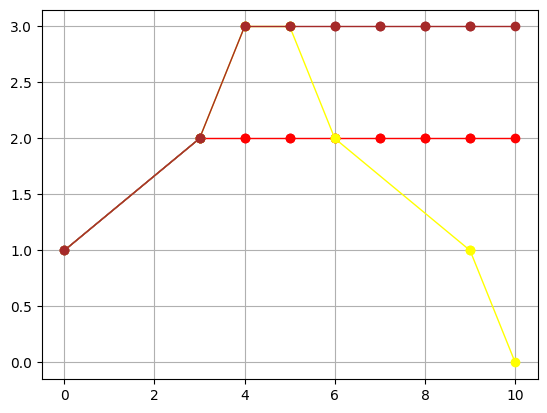

In [27]:
# Making a graph
keylist =list(sorted_results.keys())
SC_Outflow = [None]*V


for i in range(V):
    
    veh_vars=[x for x in keylist if 'sc_commodity_outflow_'+str(i) in x and sorted_results[x] >= 0.2]
    
    SC_Outflow[i] = veh_vars

print(SC_Outflow)
for i in SC_Outflow:
    print([sorted_results[x] for x in i])

#max graph size  = 100x100
graphx = [None]*T
graphy = [None]*nodes
for i in range(T):
    graphx[i] = i 
for i in range(nodes):
    graphy[i] = i

colors = ['red','green','blue','pink','yellow','brown']
for count,x in enumerate(SC_Outflow):
    for y in x:

        #plot each line indiviually, basing the thickness and color of each line on the  number and type of spacecraft
        #remember to use arcs[i][j] to plot the start and end of each line
        i = int(str(y).split(",")[1])
        j = int(str(y).split(",")[2])
        t_0 = int(str(y).split(",")[-1])
        t_end = t_0 + TOF[j][i]
        wide = sorted_results[y]

        xval = [graphx[t_0],graphx[t_end]]
        yval = [graphy[i],graphy[j]]
        plt.plot(xval,yval, linewidth = wide, marker = 'o',color=colors[count] )

plt.grid(True)    
plt.show()
        



In [24]:
# # EQUATION 7 CONSTRAINTS
#
# # Structural Fraction (fuel dependent)
# alpha = 0.045  # LOX/kerosene
#
# # Gravitational Acceleration Earth
# g_0 = 9.8  # m/s2
#
# # Upper Bound Allowed for Propellant Tank Capacity
# M_ub = 500000  # kg
#
# # Spacecraft Impulsive Burn
# t_b = 120  # s
#
#
# # Structure Mass Variable
# def create_s_star_variables(model, v=V):
#     variables = {}
#     for v in range(V):
#         variables[v] = model.addVar(vtype=GRB.CONTINUOUS, name=f'Structure_Mass_{v}')
#     return variables
#
#
# s_star = create_s_star_variables(model=m)
#
# m.update()

In [25]:
# # CONSTRAINTS 7
#
# for v in tqdm(V):
#     m.addConstr(s_star[v] = 2.3931 * )